In [ ]:
##-------------------------------------------
## Libraries & Paths

suppressMessages(library(magrittr))
suppressMessages(library(dplyr))
suppressMessages(library(GSVA))
suppressMessages(library(GSEABase))
suppressMessages(library(org.Hs.eg.db))
suppressMessages(library(AnnotationDbi))
suppressMessages(library(limma))
suppressMessages(library(tidyverse))
suppressMessages(library(matrixStats))
suppressMessages(library(DESeq2))
suppressMessages(library(edgeR))
suppressMessages(library(tidyr))
suppressMessages(library(patchwork))
suppressMessages(library(tidytext))
suppressMessages(library(ComplexHeatmap))
suppressMessages(library(ggpubr))
source("code/theme_ggplot_cfrna.R")
gene.list = read.delim("data/gencode.biotype.name.key.tsv")

In [ ]:
## NOTE: This cell reads raw ML pipeline outputs from data/ML_output_data/.
## These raw outputs are not included in the repository. Pre-computed results
## (joined_df_MECFS.csv, joined_df_TB.csv, fullpipeline_all_accuracy.csv) are
## provided in data/. This cell can be skipped if using pre-computed results.
get_data <- function(MODEL, seed, dir, METHOD){
  file <- file.path(dir, seed, comp, MODEL,
                    paste0(comp, "_", seed, ".", MODEL, ".", METHOD, ".txt"))
  all  <- read.delim(file)
  colnames(all)[1] <- paste0(MODEL, "_", METHOD)
  all %>% rownames_to_column("stat")
}

# 1. (unchanged) your function that merges train/test
get_output_stats <- function(seed, dir, models){
  all_train <- lapply(models, get_data, seed, dir, "train")
  df_train  <- Reduce(function(x,y) merge(x, y, by="stat", all.x=TRUE),
                      all_train)

  all_test  <- lapply(models, get_data, seed, dir, "test")
  df_test   <- Reduce(function(x,y) merge(x, y, by="stat", all.x=TRUE),
                      all_test)

  df_all <- merge(df_train, df_test, by="stat")

  reshape2::melt(df_all, id.var="stat") %>%
    mutate(
      method = gsub(".*_", "", variable),
      model  = gsub("_.*", "", variable)
    ) %>%
    dplyr::select(-variable) %>%
    filter(stat %in% c("auc","Accuracy","Sensitivity","Specificity")) %>%
    mutate(stat = factor(stat,
                         levels=c("auc","Specificity","Sensitivity","Accuracy")))
}

# 2. Now with a `dir` argument
get_model_results <- function(seed, dir, comp){
  # list model‐folders inside <dir>/<seed>/<comp>/
  models <- list.files(file.path(dir, seed, comp))
  models <- models[!grepl("\\.rds$|\\.png$|1_feature_selection", models)]

  # pass that same dir into get_output_stats()
  df <- get_output_stats(seed, dir, models) %>%
    mutate(split = seed)
  return(df)
}

# 3. Call it with whatever top‐level folder you like:
num_seeds  <- 50
comp       <- "KD_vs_MISC"
seeds      <- paste0("seed_", 1:num_seeds, "_all")
output_dir <- "data/ML_output_data/"

all_outputs <- lapply(seeds,
                      get_model_results,
                      dir = output_dir,
                      comp = comp)

all_df <- do.call(rbind, all_outputs)
head(all_df)

,stat,value,method,model,split
,<fct>,<dbl>,<chr>,<chr>,<chr>
1,Accuracy,1.0000000,train,EXTRATREES,seed_1_all
2,auc,1.0000000,train,EXTRATREES,seed_1_all
3,Sensitivity,1.0000000,train,EXTRATREES,seed_1_all
4,Specificity,1.0000000,train,EXTRATREES,seed_1_all
5,Accuracy,0.8620690,train,GLMNETLasso,seed_1_all
6,auc,0.9590829,train,GLMNETLasso,seed_1_all


In [12]:
read_helper <- function(path, keep = 1:2) {
  if (!file.exists(path))
    stop("File not found: ", path, call. = FALSE)

  first_line <- readLines(path, n = 1L)

  # pick delimiter: prefer tab if it’s present, otherwise comma
  sep <- if (grepl("\t", first_line, fixed = TRUE)) "\t" else ","

  read.table(path,
             sep             = sep,
             header          = TRUE,
             stringsAsFactors = FALSE,
             check.names     = FALSE,
             comment.char    = "")[, keep]
}

In [ ]:
## NOTE: The full pipeline LLM prediction files are stored as .zip archives
## in data/full pipeline/. Unzip them before running this cell.

seeds_gpt_naive    <- 1:50
seeds_gpt_informed <- 1:50
seeds_claude_informed <- 1:50
seeds_claude_naive <- 1:50

master_dir <- "data/full pipeline"

gpt_dir <- "DONE_o3_KD_MISC_"
claude_dir <- "DONE_opus4_KD_MISC_"


anno_file <- function(s) {
  file.path(master_dir, paste0(gpt_dir, "naive"), sprintf("seed_%d_all.annotation.csv", s))
}

gpt_naive <- function(s) {
  file.path(master_dir, paste0(gpt_dir, "naive"), sprintf("seed_%d_predictions.csv", s))
}

gpt_informed <- function(s) {
  file.path(master_dir, paste0(gpt_dir, "informed"), sprintf("seed_%d_disease_predictions.csv", s))
}

claude_naive <- function(s) {
  file.path(master_dir, paste0(claude_dir, "naive"), sprintf("seed_%d_claude_predictions.txt", s))
}

claude_informed <- function(s) {
  file.path(master_dir, paste0(claude_dir, "informed"), sprintf("seed_%d_claude_disease_predictions.txt", s))
}

accuracy_gpt_naive <- map_dfr(seeds_gpt_naive, function(s) {
  anno <- read.csv(anno_file(s), stringsAsFactors = FALSE)[,1:2]
  pred <- read.csv(gpt_naive(s),     stringsAsFactors = FALSE)[,1:2]
  colnames(anno) <- c("sample_id", "true_class")
  colnames(pred) <- c("sample_id", "pred_class")
  joined <- inner_join(anno, pred, by = "sample_id")
  tibble(
    seed     = s,
    gpt_naive_accuracy = mean(joined$true_class == joined$pred_class, na.rm = TRUE)
  )
}) #%>% mutate(dataset = "naive")

accuracy_gpt_informed <- map_dfr(seeds_gpt_informed, function(s) {
  anno <- read.csv(anno_file(s), stringsAsFactors = FALSE)[,1:2]
  pred <- read.csv(gpt_informed(s), stringsAsFactors = FALSE)[,1:2]
  colnames(anno) <- c("sample_id", "true_class")
  colnames(pred) <- c("sample_id", "pred_class")
  joined <- inner_join(anno, pred, by = "sample_id")
  tibble(
    seed     = s,
    gpt_informed_accuracy = mean(joined$true_class == joined$pred_class, na.rm = TRUE)
  )
}) #%>% mutate(dataset = "informed")

accuracy_claude_naive <- map_dfr(seeds_claude_naive, function(s) {
  anno <- read.csv(anno_file(s), stringsAsFactors = FALSE)[,1:2]
  pred <- read_helper(claude_naive(s))            
  colnames(anno) <- c("sample_id", "true_class")
  colnames(pred) <- c("sample_id", "pred_class")
  joined <- inner_join(anno, pred, by = "sample_id")
  tibble(
    seed     = s,
    claude_naive_accuracy = mean(joined$true_class == joined$pred_class, na.rm = TRUE)
  )
}) #%>% mutate(dataset = "informed")

accuracy_claude_informed <- map_dfr(seeds_claude_informed, function(s) {
  anno <- read.csv(anno_file(s), stringsAsFactors = FALSE)[,1:2]
  pred <- read_helper(claude_informed(s))            
  colnames(anno) <- c("sample_id", "true_class")
  colnames(pred) <- c("sample_id", "pred_class")
  joined <- inner_join(anno, pred, by = "sample_id")
  tibble(
    seed     = s,
    claude_informed_accuracy = mean(joined$true_class == joined$pred_class, na.rm = TRUE)
  )
}) #%>% mutate(dataset = "informed")

# 3) Combine  results
accuracy_tbl <- accuracy_gpt_informed %>%
  inner_join(accuracy_gpt_naive,   by = "seed") %>%
  inner_join(accuracy_claude_naive, by = "seed") %>%
  inner_join(accuracy_claude_informed, by = "seed")

head(accuracy_tbl)

seed,gpt_informed_accuracy,gpt_naive_accuracy,claude_naive_accuracy,claude_informed_accuracy
<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.8367347,0.7551020,0.6122449,0.5918367
2,0.7959184,0.8367347,0.4693878,0.5510204
3,0.8979592,0.8367347,0.5714286,0.5510204
4,0.7959184,0.8367347,0.4897959,0.5306122
5,0.9183673,0.9387755,0.5918367,0.6122449
6,0.8163265,0.8163265,0.6530612,0.5714286


In [14]:
# ── 1) pull the accuracy rows and keep the model identifier ────────────────
ml_df <- all_df %>% 
  filter(method == "test",
         stat   == "Accuracy",
         model  %in% c("GLMNETLasso", "RF", "EXTRATREES",
                       "GLMNETRidge", "NNET")) %>%   # keep only the 5 models
  mutate(seed = as.integer(str_extract(split, "\\d+"))) %>%  # extract seed
  dplyr::select(seed, model, value)                                # value == accuracy

# ── 2) make one column per model ───────────────────────────────────────────
ml_df_wide <- ml_df %>% 
  pivot_wider(names_from  = model,
              values_from = value,
              names_glue  = "{model}_accuracy")      # optional suffix

# ── 3) join on seed ────────────────────────────────────────────────────────
joined_df <- inner_join(accuracy_tbl, ml_df_wide, by = "seed")

In [15]:
head(joined_df)

seed,gpt_informed_accuracy,gpt_naive_accuracy,claude_naive_accuracy,claude_informed_accuracy,EXTRATREES_accuracy,GLMNETLasso_accuracy,GLMNETRidge_accuracy,NNET_accuracy,RF_accuracy
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.8367347,0.7551020,0.6122449,0.5918367,0.8775510,0.8979592,0.8775510,0.8571429,0.8775510
2,0.7959184,0.8367347,0.4693878,0.5510204,0.8571429,0.8775510,0.8979592,0.8367347,0.8367347
3,0.8979592,0.8367347,0.5714286,0.5510204,0.7959184,0.8571429,0.8775510,0.8775510,0.7959184
4,0.7959184,0.8367347,0.4897959,0.5306122,0.8571429,0.8163265,0.8367347,0.8367347,0.8571429
5,0.9183673,0.9387755,0.5918367,0.6122449,0.8775510,0.8775510,0.8367347,0.8367347,0.8775510
6,0.8163265,0.8163265,0.6530612,0.5714286,0.8367347,0.7959184,0.8571429,0.9183673,0.8163265


In [16]:
# ── 1) reshape to long form ────────────────────────────────────────────────
plot_df <- joined_df %>%                                 # has *_accuracy cols
  dplyr::select(seed, ends_with("_accuracy")) %>%               # keep all accuracy cols
  pivot_longer(cols = -seed,
               names_to  = "Model",
               values_to = "Accuracy") %>%
  mutate(Model = str_remove(Model, "_accuracy"))

# ── 2) force the desired order (LLM pipelines first) ───────────────────────
model_levels <- c("gpt_informed", "gpt_naive", "claude_informed", "claude_naive",
                  "GLMNETLasso", "GLMNETRidge",
                  "RF", "EXTRATREES", "NNET")
plot_df <- plot_df %>%
  mutate(Model = factor(Model, levels = model_levels))

# ── 3) pairwise comparisons vs. "informed" (⬅ change if you prefer) ────────
comparisons <- list(
  c("claude_informed", "claude_naive"),
      c("gpt_informed", "gpt_naive"),
  c("gpt_informed", "GLMNETLasso")
)

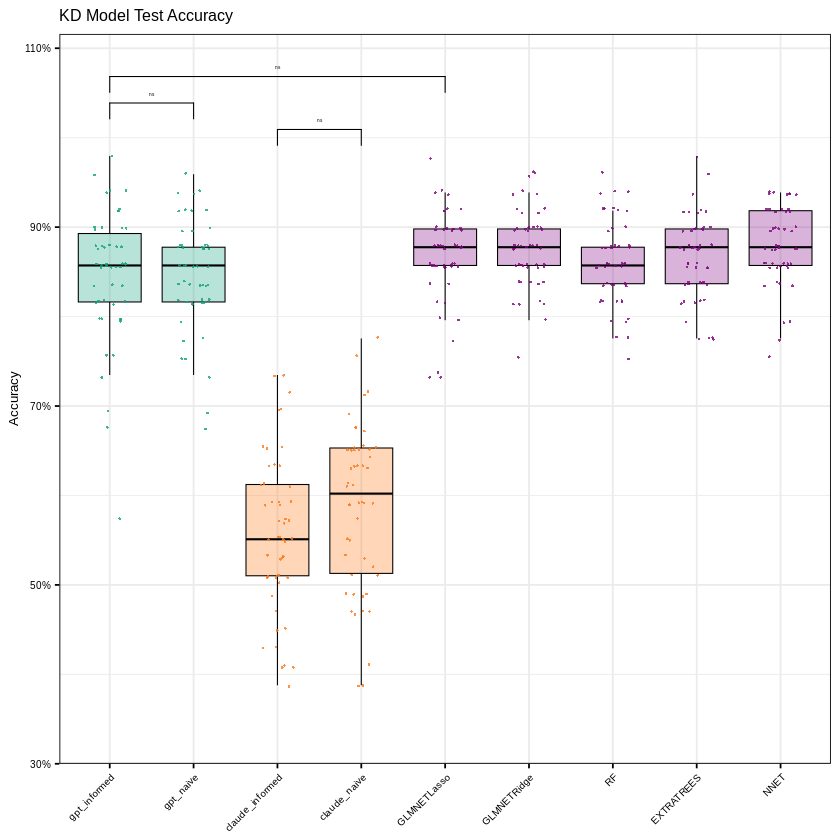

In [ ]:
# base colours
cols <- c(
  "claude_informed" = "#ff7613",  # orange
  "claude_naive"    = "#ff7613",  
  "gpt_informed"    = "#10a37f",  # teal-green
  "gpt_naive"       = "#10a37f"
)

# one cohesive colour for every remaining model
other_colour  <- "#800080"  # purple (contrasts but still cohesive)
other_models  <- setdiff(levels(plot_df$Model), names(cols))
cols          <- c(cols,
                   setNames(rep(other_colour, length(other_models)),
                             other_models))


ggplot(
  plot_df,
  aes(x = Model, y = Accuracy, fill = Model, colour = Model)  # colour mapped too
) +
  geom_boxplot(
    colour = "black",
    lwd = .3,
    outlier.shape = NA,
    alpha = 0.3                                           # 30 % opacity boxes
  ) +
  geom_jitter(
    width  = .2,
    size   = .4,
    alpha  = .8,
    shape  = 16                                           # points inherit colour = Model
  ) +
  stat_compare_means(
    comparisons   = comparisons,
    label         = "p.signif",
    size          = 1,
    step.increase = 0.05,
    hide.ns       = FALSE
  ) +
  scale_y_continuous(
    limits = c(0.3, 1.1),
    labels = scales::percent_format(accuracy = 1),
    expand = expansion(mult = c(0, 0.02))
  ) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +                    # palette for jitter colours
  labs(
    x     = NULL,
    y     = "Accuracy",
    title = "KD Model Test Accuracy"
  ) +
  theme_cfrna_print() +
  theme(
    legend.position = "none",
    axis.text.x     = element_text(angle = 45, hjust = 1)
  )

#dev.off()

In [ ]:
MECFS_table = read.csv("data/joined_df_MECFS.csv", row.names = 1)
TB_table = read.csv("data/joined_df_TB.csv", row.names = 1)

In [ ]:
library(broom)

#---------- Helper function to run all pairwise tests for one condition ---------
pairwise_t_tests <- function(df, condition_label, seed_col = "seed") {
  
  # If the seed column name differs or does not exist, adjust/remove the select below.
  if (seed_col %in% names(df)) {
    model_cols <- df %>%
      dplyr::select(-all_of(seed_col)) %>%
      dplyr::select(where(is.numeric)) %>%
      colnames()
  } else {
    model_cols <- df %>%
      dplyr::select(where(is.numeric)) %>%
      colnames()
  }
  
  run_one_t <- function(vec1, vec2, m1, m2, paired = TRUE) {
    tt <- t.test(vec1, vec2, paired = paired)
    broom::tidy(tt) %>%
      mutate(model_1 = m1,
             model_2 = m2,
             paired  = paired) %>%
      dplyr::select(model_1, model_2, paired,
                    t = statistic,
                    p = p.value)
  }
  
  pairs <- combn(model_cols, 2, simplify = FALSE)
  
  paired_results <- map_dfr(
    pairs,
    ~ run_one_t(df[[.x[1]]], df[[.x[2]]], .x[1], .x[2], paired = TRUE)
  )
  
  unpaired_results <- map_dfr(
    pairs,
    ~ run_one_t(df[[.x[1]]], df[[.x[2]]], .x[1], .x[2], paired = FALSE)
  )
  
  all_results <- bind_rows(paired_results, unpaired_results) %>%
    group_by(paired) %>%
    mutate(
      p_adj_BH   = p.adjust(p, method = "BH"),
      p_adj_bonf = p.adjust(p, method = "bonferroni")
    ) %>%
    ungroup() %>%
    mutate(condition = condition_label) %>%
    dplyr::select(condition, model_1, model_2, paired, t, p, p_adj_BH, p_adj_bonf)
  
  all_results
}

#---------- Generate results for each condition ----------
kd_results     <- pairwise_t_tests(joined_df,    "KD")      # joined_df is your KD table
tb_results     <- pairwise_t_tests(TB_table,     "TB")
mecfs_results  <- pairwise_t_tests(MECFS_table,  "MECFS")

#---------- Master dataframe (all conditions combined) ----------
master_results <- bind_rows(kd_results, tb_results, mecfs_results) %>%
  arrange(condition, !paired, model_1, model_2)


In [19]:
########################################################################
## 0)  Assemble a single long data-frame with a “Condition” column
########################################################################
kd_df     <- joined_df     %>% mutate(Condition = "KD")
tb_df     <- TB_table      %>% mutate(Condition = "TB")
mecfs_df  <- MECFS_table   %>% mutate(Condition = "MECFS")

plot_df <- bind_rows(kd_df, tb_df, mecfs_df) %>%          # combine
  dplyr::select(Condition, seed, ends_with("_accuracy")) %>%
  pivot_longer(cols = -c(Condition, seed),
               names_to  = "Model",
               values_to = "Accuracy") %>%
  mutate(Model     = str_remove(Model, "_accuracy"),
         Model     = factor(Model, levels = c(
           "gpt_informed", "gpt_naive", "claude_informed", "claude_naive",
           "GLMNETLasso", "GLMNETRidge", "RF", "EXTRATREES", "NNET"
         )),
         Condition = factor(Condition, levels = c("KD", "TB", "MECFS")))

########################################################################
## 1)  Define per-facet comparison lists (edit as you wish)
########################################################################
comp_KD    <- list(c("claude_informed", "claude_naive"),
                   c("gpt_informed",    "gpt_naive"),
                   c("gpt_informed",    "GLMNETLasso"))

comp_TB    <- list(c("claude_informed",    "claude_naive"),
                   c("gpt_informed",    "gpt_naive"),
                   c("gpt_informed",    "GLMNETLasso"))

comp_MECFS <- list(c("gpt_informed",    "gpt_naive"),
                   c("claude_informed",    "claude_naive"),
                   c("gpt_informed",    "GLMNETLasso"),
                   c("gpt_naive",    "GLMNETLasso"), 
                   c("claude_informed",    "GLMNETLasso"))

########################################################################
## 2)  Colour palette (same logic as before)
########################################################################
cols <- c(
  "claude_informed" = "#ff7613",
  "claude_naive"    = "#ff7613",
  "gpt_informed"    = "#10a37f",
  "gpt_naive"       = "#10a37f"
)
other_colour <- "#800080"
other_models <- setdiff(levels(plot_df$Model), names(cols))
cols         <- c(cols, setNames(rep(other_colour, length(other_models)),
                                 other_models))

In [ ]:
full_df <- bind_rows(kd_df, tb_df, mecfs_df)
write.csv(full_df, "data/fullpipeline_all_accuracy.csv")

In [ ]:
########################################################################
## 3)  Faceted plot  (one PDF, three panels)
########################################################################
pdf("figures/fullpipeline_all_conditions.pdf", width = 7, height = 3.5)

## ──────────────────────────────────────────────────────────────────
## A  identify which x-axis levels are your “standard workflow”
##    (adjust the vector if you rename / add models)
## ──────────────────────────────────────────────────────────────────
std_models <- c("GLMNETLasso", "GLMNETRidge",
                "RF", "EXTRATREES", "NNET")

## current order of Model on the x-axis
x_levels <- levels(plot_df$Model)

## B  build a small data-frame of grey rectangles,
##    one for every facet & standard column
library(dplyr)

shade_df <- expand.grid(
  Condition = unique(plot_df$Condition),      # facet rows
  Model     = std_models                      # grey columns
) %>%
  mutate(
    Model = factor(Model, levels = x_levels), # keep factor order
    xmin  = as.numeric(Model) - 0.5,
    xmax  = as.numeric(Model) + 0.5,
    ymin  = -Inf,
    ymax  =  Inf
  )

ggplot(plot_df, aes(x = Model, y = Accuracy,
                    fill = Model, colour = Model)) +
  ## C  pale-grey backdrop behind “standard” columns
  geom_rect(data = shade_df,
            aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax),
            inherit.aes = FALSE,
            fill  = "grey90",
            alpha = 0.6) +

  geom_boxplot(colour = "black", lwd = .25,
               outlier.shape = NA, alpha = 0.30) +
  geom_jitter(width = .2, size = .5, alpha = .8, shape = 16) +

  ## per-facet significance layers  (unchanged) ----------------------
  stat_compare_means(
      data        = subset(plot_df, Condition == "KD"),
      comparisons = comp_KD,
      label       = "p.signif",
      size        = 2, label.y = 0.95,
      step.increase = 0.08, hide.ns = FALSE) +
  stat_compare_means(
      data        = subset(plot_df, Condition == "TB"),
      comparisons = comp_TB,
      label       = "p.signif",
      size        = 2, label.y = 0.92,
      step.increase = 0.08, hide.ns = FALSE) +
  stat_compare_means(
      data        = subset(plot_df, Condition == "MECFS"),
      comparisons = comp_MECFS,
      label       = "p.signif",
      size        = 2, label.y = 0.80,
      step.increase = 0.08, hide.ns = FALSE) +

  ## D  axis, fill, facet & theme  (same as before) -----------------
  scale_y_continuous(
      limits = c(0.3, 1.12),
      labels = scales::percent_format(accuracy = 1),
      expand = expansion(mult = c(0, 0.02))) +
  scale_fill_manual(values = cols) +
  scale_colour_manual(values = cols) +
  facet_wrap(~ Condition, nrow = 1) +
  labs(x = NULL, y = "Accuracy",
       title = NULL) +
  theme_cfrna_print() +
  theme(
      legend.position = "none",
      strip.text = element_text(size = 8,
                    margin = margin(t = 4, r = 4, b = 4, l = 4)),
      axis.text.x = element_text(angle = 45, hjust = 1))

dev.off()

pdf 
  2